# NDT7 EDA — Myanmar (พม่า)

วิเคราะห์ความเร็วเน็ต M-Lab NDT7 (2023–2025) — โครงเดียวกับ `ndt7_singapore_eda`

- **ข้อมูล:** `mlab_mm_clean.parquet` · หน่วยพื้นที่ รัฐ/ภาค 14/15 (ไม่มีเทสต์: Rakhine (ยะไข่))
- **category:** Consumer Broadband 79.0% · Mobile 15.8% · Hosting 5.2%
- **แนวทาง:** section 1–2 ครบ 3 network_type · section 3–7 เน้นผู้ใช้จริง (broadband + cellular, ตัด Hosting/Datacenter)
- **แผนที่:** GADM 4.1 ADM1 (gadm.org) · **ประชากรเมือง:** สำมะโนประชากรพม่า 2014 (Dept. of Population)

In [1]:
COUNTRY    = "Myanmar"
UNIT_TH    = "รัฐ/ภาค"
UNIT_EN    = "state/region"
DOC_MEDIAN = 11.1

PARQUET_CANDS = [
    r"../../data/mm/mlab_mm_clean.parquet",
    r"data/mm/mlab_mm_clean.parquet",
]
GEOJSON_CANDS = [
    r"../../data/mm/myanmar_provinces.geojson",
    r"data/mm/myanmar_provinces.geojson",
]

CAPITAL    = "Nay Pyi Taw"
TOP_CITIES = [
    ("Yangon", "5.21M"),
    ("Mandalay", "1.22M"),
    ("Nay Pyi Taw", "1.16M"),
    ("Mawlamyine", "491k"),
    ("Taunggyi", "381k"),
]

In [2]:
import duckdb, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import geopandas as gpd
from pathlib import Path
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10.5,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
})
NT_COLOR = {"broadband": "#e63946", "cellular": "#8ecae6", "hosting": "#8E7DBE"}
NAVY = "#0B1F3A"

METRICS = [
    dict(key="dl",  label="Median download (Mbps)",        cmap="RdYlGn",   hcmap="YlOrRd"),
    dict(key="ul",  label="Median upload (Mbps)",          cmap="RdYlGn",   hcmap="YlOrRd"),
    dict(key="rtt", label="Median latency min_rtt (ms)",   cmap="RdYlGn_r", hcmap="YlGnBu"),
]
NETS      = ["broadband", "cellular", "hosting"]
USER_NETS = ["broadband", "cellular"]

def _first(cands, base):
    for c in cands:
        p = (base / c).resolve()
        if p.exists():
            return p
    return (base / cands[0]).resolve()

BASE    = Path.cwd()
PARQUET = _first(PARQUET_CANDS, BASE)
GEOJSON = _first(GEOJSON_CANDS, BASE)
print("parquet:", PARQUET.exists(), PARQUET.name, "| geojson:", GEOJSON.exists(), GEOJSON.name)

FIG_DIR = (BASE / "figures").resolve()
FIG_DIR.mkdir(exist_ok=True)
def savefig(name):
    plt.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
print("figures ->", FIG_DIR)

con = duckdb.connect()
P = f"""(SELECT *,
          EXTRACT(year  FROM date)      AS year,
          EXTRACT(month FROM date)      AS month,
          EXTRACT(hour  FROM test_time) AS hour
        FROM read_parquet('{PARQUET.as_posix()}'))"""

AGG = """MEDIAN(CASE WHEN type='download' THEN mean_throughput_mbps END) AS dl,
         MEDIAN(CASE WHEN type='upload'   THEN mean_throughput_mbps END) AS ul,
         MEDIAN(min_rtt)                                                 AS rtt"""

TOTAL = con.execute(f"SELECT COUNT(*) FROM {P}").fetchone()[0]
MIN_N     = max(50,  round(TOTAL * 0.0002))
ISP_MIN   = max(500, round(TOTAL / 300))
CITY_FLAG = 1000
print(f"total rows: {TOTAL:,} | MIN_N={MIN_N} | ISP_MIN={ISP_MIN:,}")

PROV_ORDER = con.execute(f"""
    SELECT province FROM {P}
    WHERE category <> 'Hosting/Datacenter'
    GROUP BY province ORDER BY COUNT(*) DESC
""").df()["province"].tolist()
print(f"{len(PROV_ORDER)} units:", PROV_ORDER)

parquet: True mlab_mm_clean.parquet | geojson: True myanmar_provinces.geojson
figures -> E:\KasetUni_(KU)\CNC\Internet-Measurement\Dataset\speedtest-ndt7\mm\mm_clean\figures
total rows: 2,115,739 | MIN_N=423 | ISP_MIN=7,052
14 units: ['Mandalay', 'Yangon', 'Ayeyarwady', 'Shan', 'Bago', 'Kayah', 'Naypyitaw', 'Kachin', 'Kayin', 'Tanintharyi', 'Magway', 'Mon', 'Sagaing', 'Chin']


## 1. Setup & sanity check
ภาพรวมต่อ `network_type` (ครบ 3) + เทียบ category share กับเอกสาร

In [3]:
overview = con.execute(f"""
    SELECT network_type,
           COUNT(*) AS n_tests,
           {AGG}, ROUND(AVG(loss_rate), 4) AS mean_loss
    FROM {P} GROUP BY network_type ORDER BY n_tests DESC
""").df().round(1)
overview["share_%"] = (overview["n_tests"] / TOTAL * 100).round(1)

cat = con.execute(f"""
    SELECT category, COUNT(*) n, ROUND(100.0*COUNT(*)/{TOTAL}, 1) AS pct
    FROM {P} GROUP BY category ORDER BY n DESC
""").df()

print(f"total rows: {TOTAL:,}")
bb_med = overview.loc[overview.network_type == "broadband", "dl"].values
print(f"broadband median download = {bb_med[0] if len(bb_med) else float('nan')} Mbps "
      f"(เอกสารรายงาน median รวม ~{DOC_MEDIAN})")
print("category share (เทียบเอกสาร):")
print(cat.to_string(index=False))
overview

total rows: 2,115,739
broadband median download = 12.4 Mbps (เอกสารรายงาน median รวม ~11.1)
category share (เทียบเอกสาร):
          category       n  pct
Consumer Broadband 1671466 79.0
            Mobile  333779 15.8
Hosting/Datacenter  110494  5.2


,network_type,n_tests,dl,ul,rtt,mean_loss,share_%
0,broadband,1671466,12.4,10.8,85.9,0.1,79.0
1,cellular,333779,9.9,4.6,99.8,0.0,15.8
2,hosting,110494,17.7,9.1,37.0,0.0,5.2


## 2. Distribution — Download / Upload / Latency (แยก 3 ส่วน · ส่วนละ broadband/cellular/hosting)
แกน x เป็น log (ข้อมูลเบ้ขวา) แต่**ป้าย tick เป็นเลขจริง** (1, 3, 10, 30, 100, …) · เส้นประ = median · แกน y = จำนวนเทสต์ (sampled)

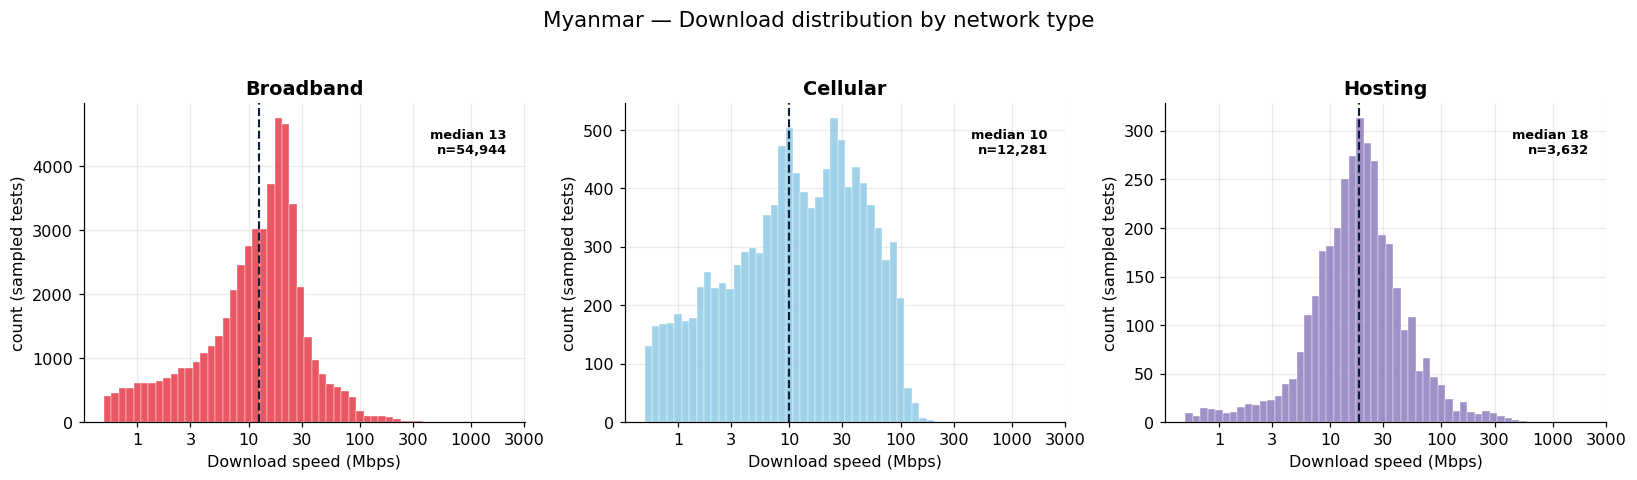

In [4]:
def dist_row(key, xlabel, title, save):
    if key == "rtt":  col, cond, lo = "min_rtt", "", 1
    elif key == "dl": col, cond, lo = "mean_throughput_mbps", "AND type='download'", 0.5
    else:             col, cond, lo = "mean_throughput_mbps", "AND type='upload'", 0.5
    bins = np.logspace(np.log10(lo), np.log10(2000), 55)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    for ax, nt in zip(axes, NETS):
        v = con.execute(f"SELECT {col} v FROM {P} WHERE network_type='{nt}' AND {col}>0 {cond} "
                        f"USING SAMPLE 120000 ROWS").df()["v"].values
        if len(v) == 0:
            ax.text(0.5, 0.5, "no data", transform=ax.transAxes, ha="center"); continue
        ax.hist(v, bins=bins, color=NT_COLOR[nt], alpha=0.85, edgecolor="white", linewidth=0.3)
        med = float(np.median(v))
        ax.axvline(med, color=NAVY, ls="--", lw=1.4)
        ax.set_xscale("log")
        ax.xaxis.set_major_locator(mticker.LogLocator(base=10, subs=(1.0, 3.0)))
        ax.xaxis.set_minor_locator(mticker.NullLocator())
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:g}"))
        ax.text(0.96, 0.92, f"median {med:.0f}\nn={len(v):,}", transform=ax.transAxes,
                ha="right", va="top", fontsize=8.5, fontweight="bold")
        ax.set_title(nt.capitalize(), fontweight="bold")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("count (sampled tests)")
    plt.suptitle(f"{COUNTRY} — {title} distribution by network type", fontsize=14, y=1.03)
    plt.tight_layout(); savefig(save); plt.show()

dist_row("dl", "Download speed (Mbps)", "Download", "02_dist_download")

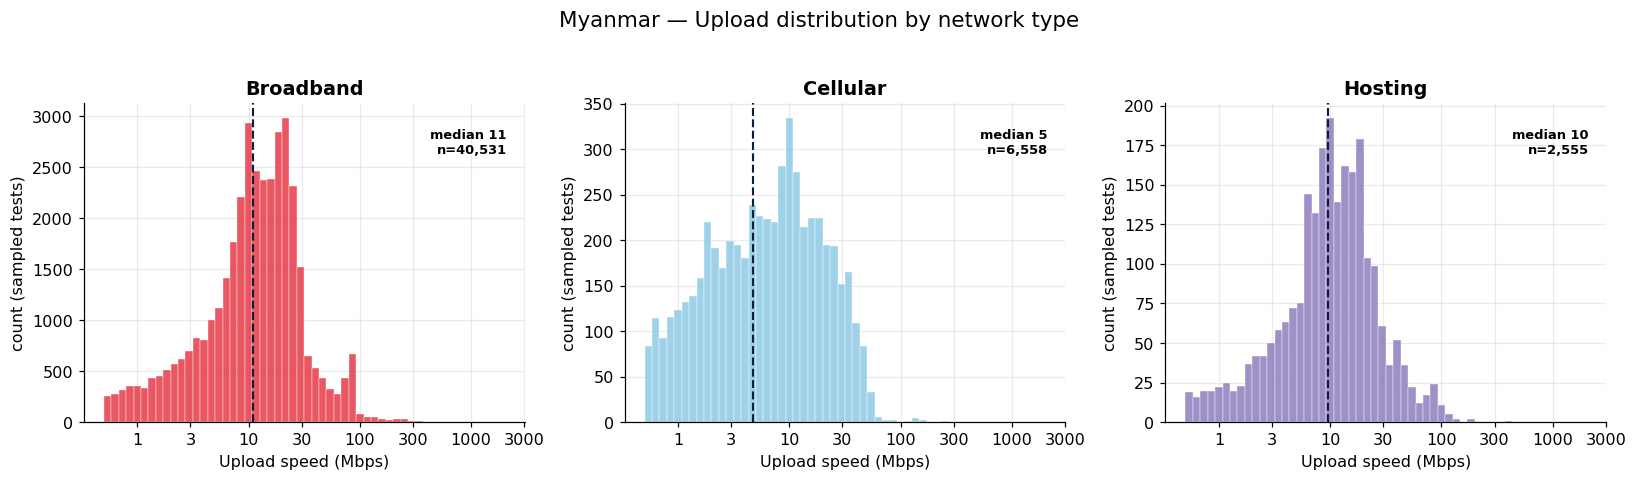

In [5]:
dist_row("ul", "Upload speed (Mbps)", "Upload", "02_dist_upload")

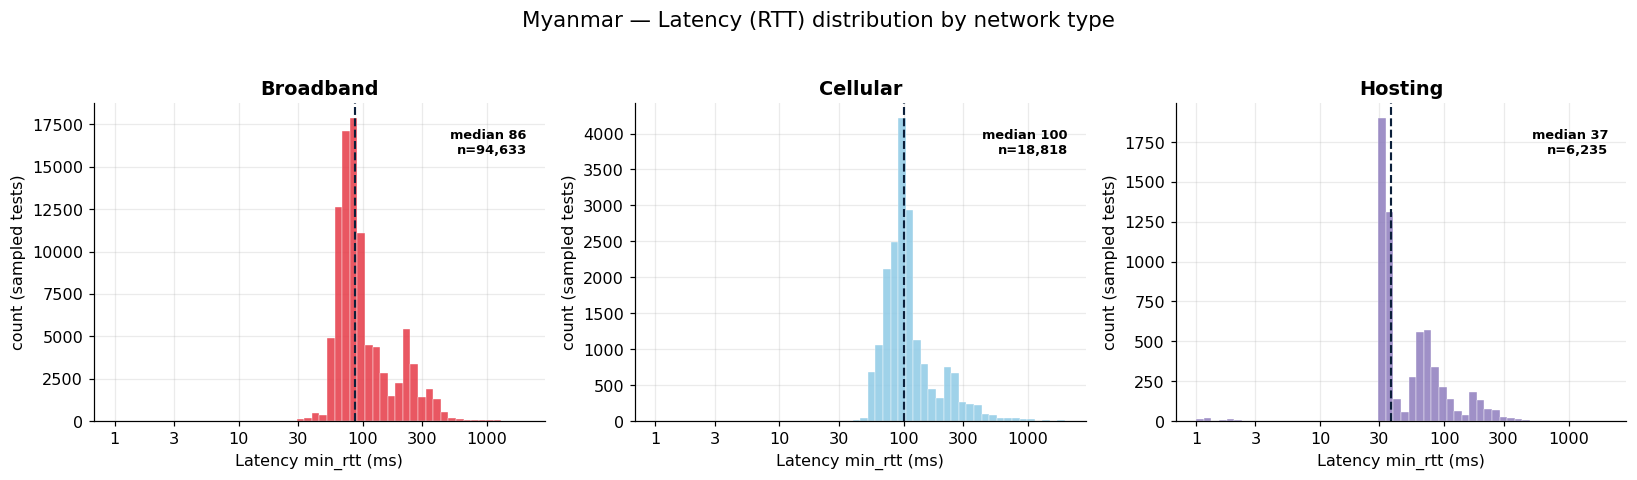

In [6]:
dist_row("rtt", "Latency min_rtt (ms)", "Latency (RTT)", "02_dist_rtt")

## 3. เทียบราย รัฐ/ภาค — broadband vs cellular
แท่งแนวนอน เรียงตามปริมาณเทสต์ · ตัด hosting (เน้นผู้ใช้จริง)

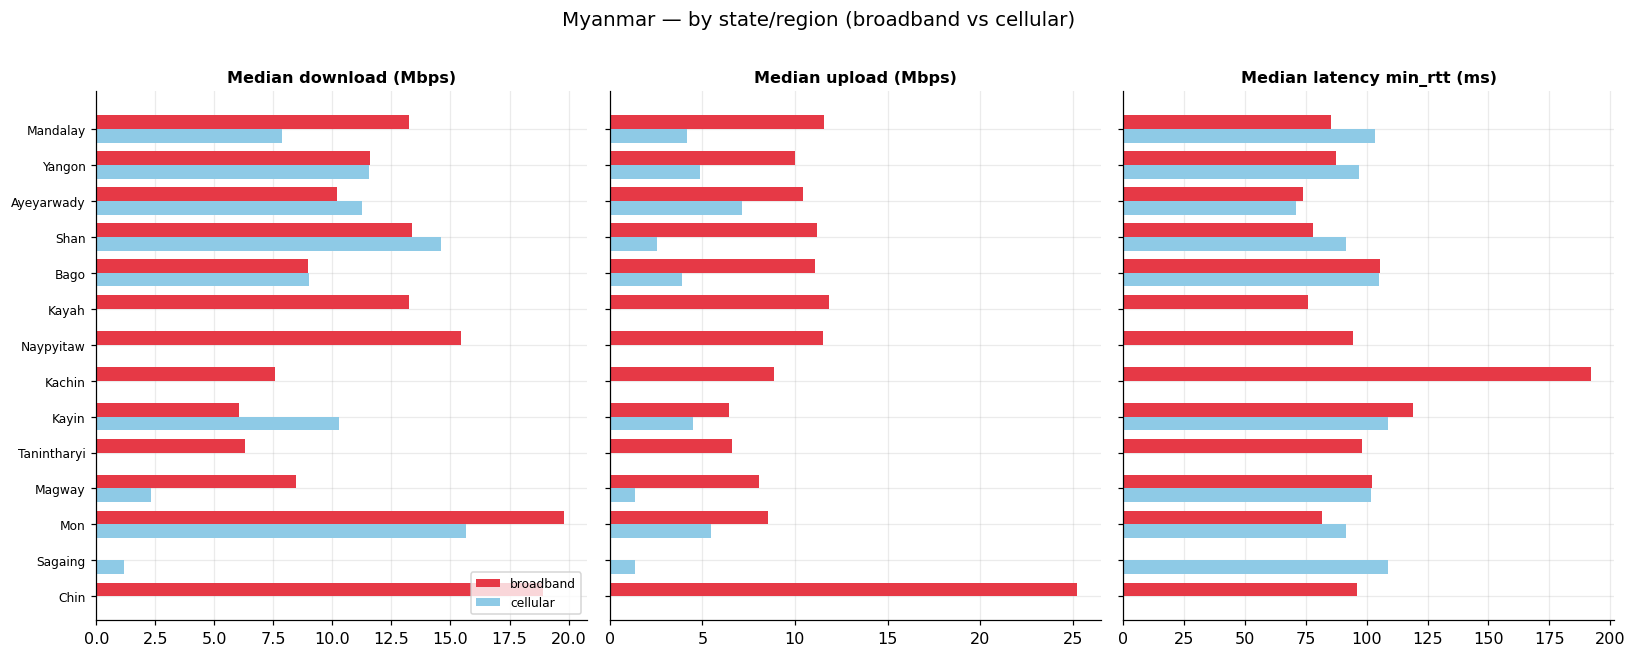

In [7]:
rm = con.execute(f"""
    SELECT province, network_type, {AGG}, AVG(loss_rate) AS loss, COUNT(*) AS n
    FROM {P} WHERE category <> 'Hosting/Datacenter'
    GROUP BY province, network_type
""").df()

order = PROV_ORDER[::-1]
y = np.arange(len(order)); h = 0.38
fig, axes = plt.subplots(1, 3, figsize=(15, max(5, 0.42*len(order))), sharey=True)
for ax, m in zip(axes, METRICS):
    piv = rm.pivot(index="province", columns="network_type", values=m["key"]).reindex(order)
    for i, nt in enumerate(USER_NETS):
        vals = piv[nt] if nt in piv else pd.Series(index=order, dtype=float)
        ax.barh(y + (0.5 - i)*h, vals, h, label=nt, color=NT_COLOR[nt])
    ax.set_yticks(y); ax.set_yticklabels(order, fontsize=8)
    ax.set_title(m["label"], fontsize=10.5, fontweight="bold")
axes[0].legend(fontsize=8, loc="lower right")
plt.suptitle(f"{COUNTRY} — by {UNIT_EN} (broadband vs cellular)", fontsize=13, y=1.01)
plt.tight_layout(); savefig("03_provincial_bar"); plt.show()

## 4. Heatmap รายไตรมาส (รัฐ/ภาค × quarter)
ตัดเซลล์ที่ n < MIN_N (ปรับอัตโนมัติตามขนาดข้อมูล)

quarters: 12 | 2023-Q1 -> 2025-Q4 | MIN_N = 423


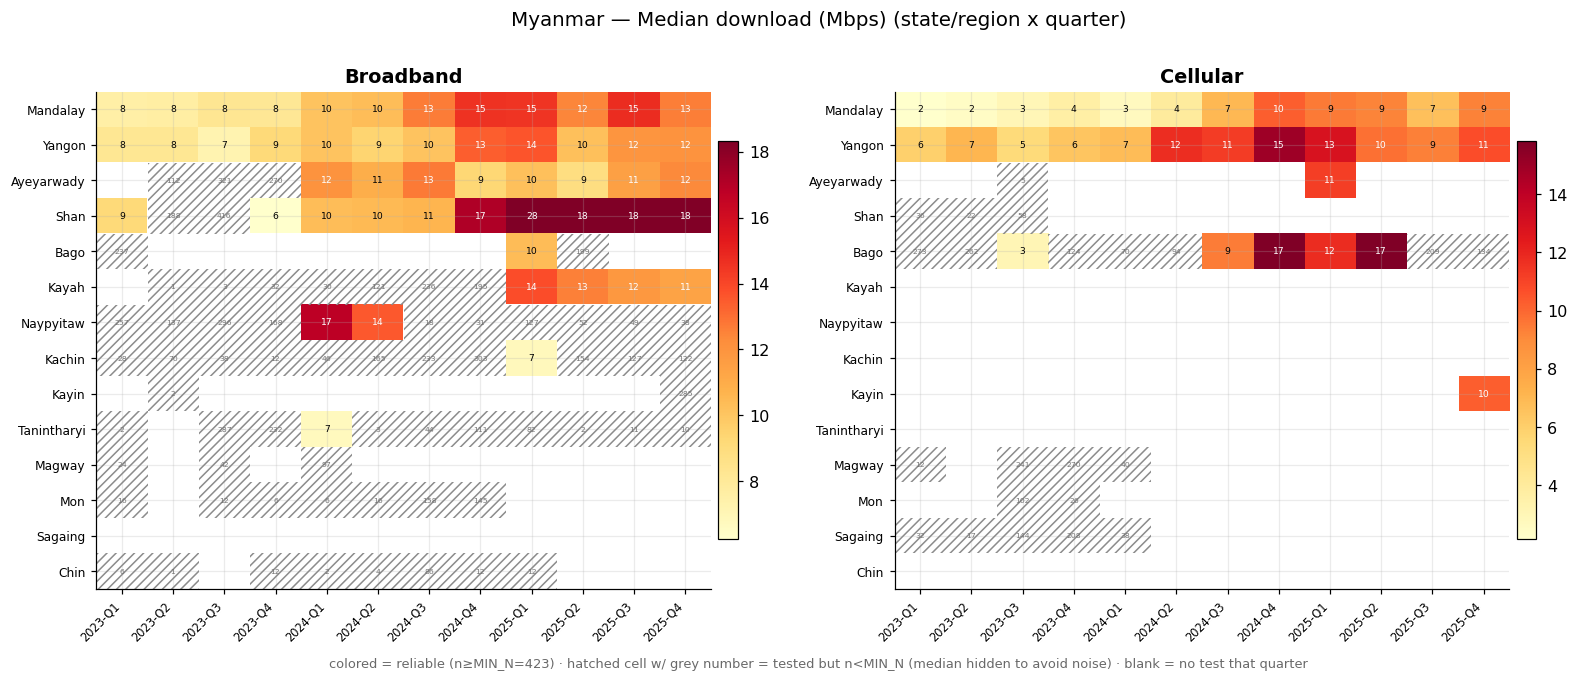

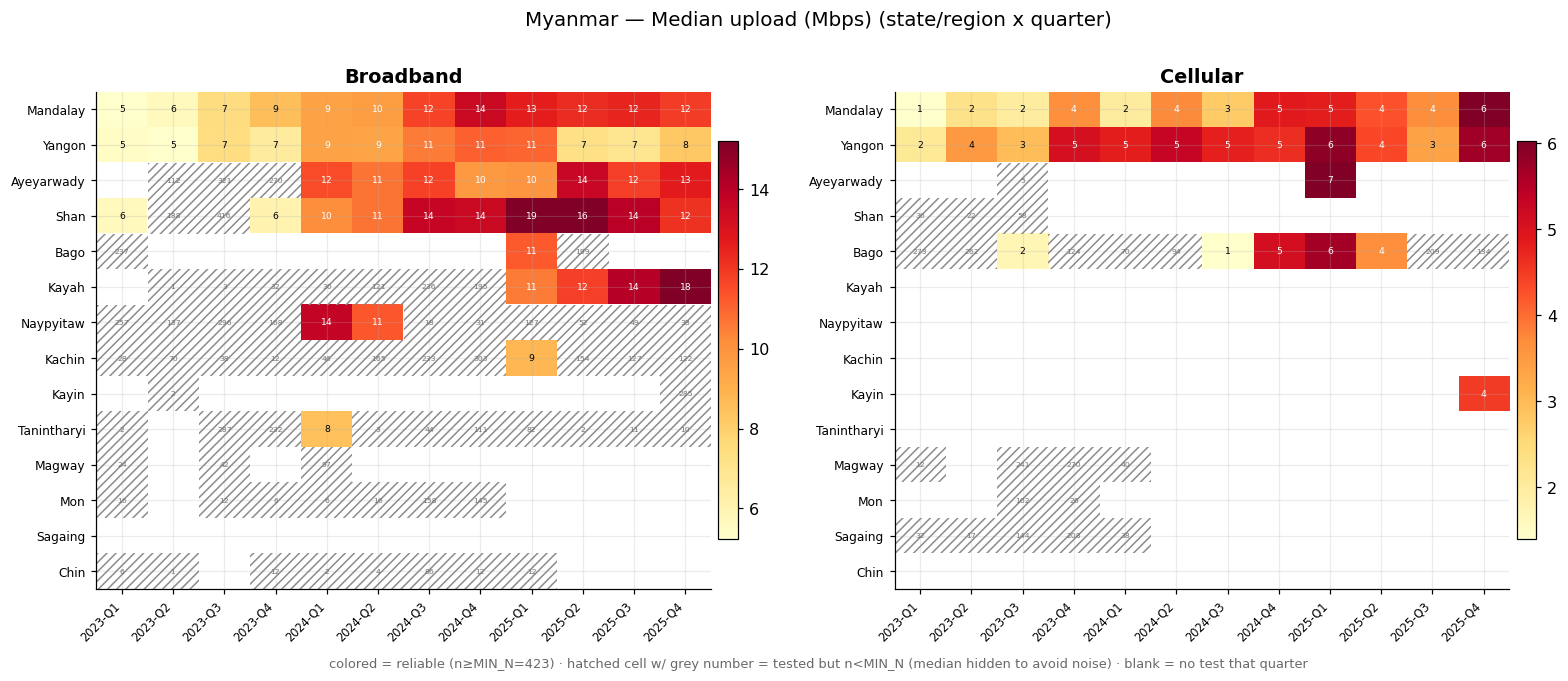

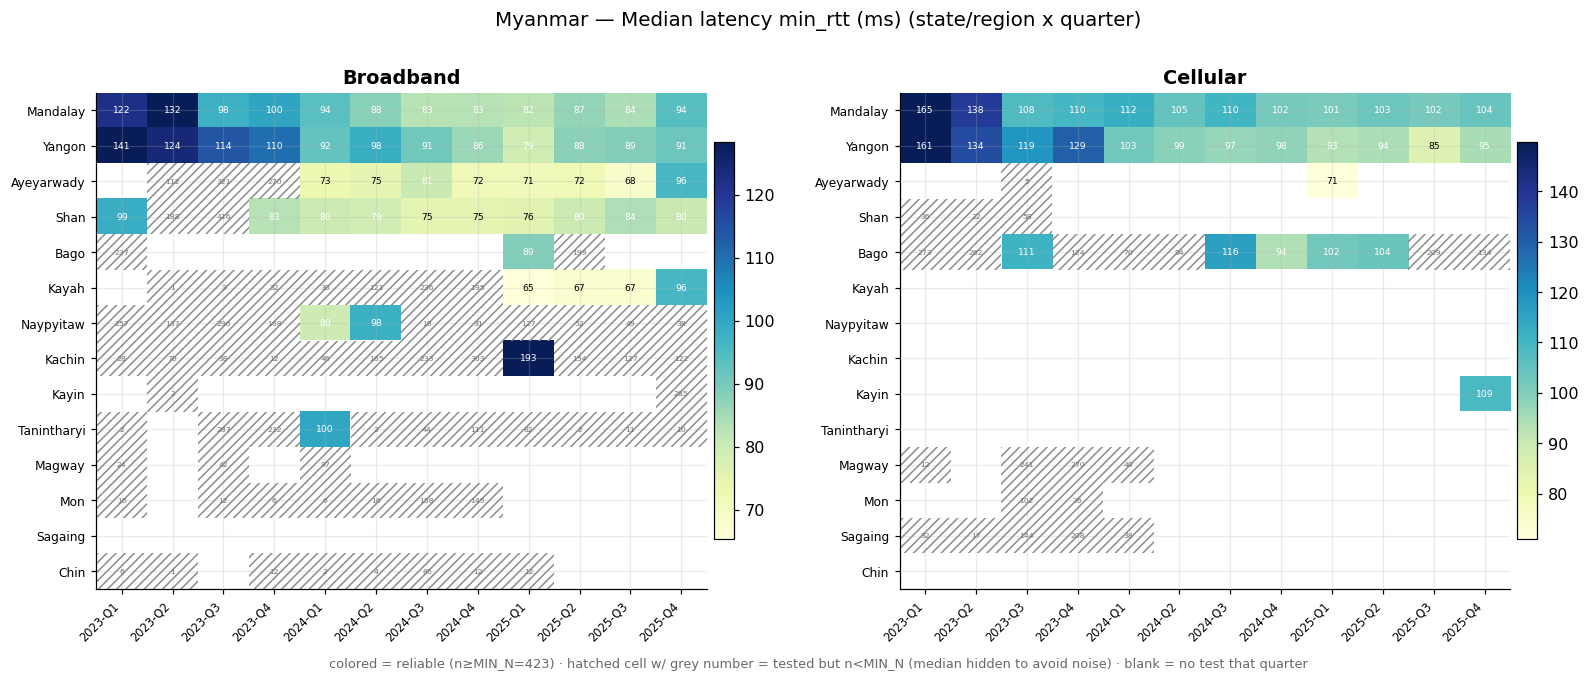

In [8]:
qtr = con.execute(f"""
    SELECT province, network_type, year, ((month-1)//3 + 1) AS q,
           make_date(year, CAST(((month-1)//3)*3 + 1 AS INT), 1) AS period_start,
           {AGG}, COUNT(*) AS n
    FROM {P} WHERE category <> 'Hosting/Datacenter'
    GROUP BY province, network_type, year, q, period_start ORDER BY period_start
""").df()
qtr["label"] = qtr["year"].astype(str) + "-Q" + qtr["q"].astype(int).astype(str)
Q_ORDER = qtr.sort_values("period_start")["label"].unique().tolist()
for k in ["dl", "ul", "rtt"]:
    qtr.loc[qtr["n"] < MIN_N, k] = np.nan
print("quarters:", len(Q_ORDER), "|", Q_ORDER[0], "->", Q_ORDER[-1], "| MIN_N =", MIN_N)

def heatmap_q(nt, m, ax):
    d = qtr[qtr.network_type == nt]
    piv  = d.pivot_table(index="province", columns="label", values=m["key"]).reindex(PROV_ORDER).reindex(columns=Q_ORDER)
    npiv = d.pivot_table(index="province", columns="label", values="n", aggfunc="sum").reindex(PROV_ORDER).reindex(columns=Q_ORDER)
    if np.all(np.isnan(piv.values)) and np.all(np.isnan(npiv.values)):
        ax.text(0.5, 0.5, "no data", transform=ax.transAxes, ha="center"); return None
    vmax = np.nanpercentile(piv.values, 95); vmin = np.nanmin(piv.values)
    im = ax.imshow(piv.values, aspect="auto", cmap=m["hcmap"], vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(Q_ORDER))); ax.set_xticklabels(Q_ORDER, rotation=45, ha="right", fontsize=7.5)
    ax.set_yticks(range(len(PROV_ORDER))); ax.set_yticklabels(PROV_ORDER, fontsize=8)
    ax.set_title(nt.capitalize(), fontweight="bold")
    for r in range(piv.shape[0]):
        for c in range(piv.shape[1]):
            val = piv.values[r, c]; nval = npiv.values[r, c]
            if not np.isnan(val):
                ax.text(c, r, f"{val:.0f}", ha="center", va="center", fontsize=6,
                        color="white" if val > vmax*0.6 else "black")
            elif not np.isnan(nval) and nval > 0:
                ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, fill=False,
                             hatch="////", edgecolor="0.55", linewidth=0.0))
                ax.text(c, r, f"{int(nval)}", ha="center", va="center", fontsize=5, color="0.45")
    return im

for m in METRICS:
    fig, axes = plt.subplots(1, 2, figsize=(15, max(4, 0.42*len(PROV_ORDER))))
    for ax, nt in zip(axes, USER_NETS):
        im = heatmap_q(nt, m, ax)
        if im is not None: fig.colorbar(im, ax=ax, shrink=0.8, pad=0.01)
    plt.suptitle(f"{COUNTRY} — {m['label']} ({UNIT_EN} x quarter)", fontsize=13, y=1.005)
    fig.text(0.5, -0.01,
             f"colored = reliable (n≥MIN_N={MIN_N}) · hatched cell w/ grey number = tested but n<MIN_N "
             f"(median hidden to avoid noise) · blank = no test that quarter",
             ha="center", fontsize=8.5, color="dimgray")
    plt.tight_layout(); savefig(f"04_heatmap_{m['key']}"); plt.show()

## 5. Growth index ราย รัฐ/ภาค
โฟกัส broadband (base = ไตรมาสแรกที่ทุกพื้นที่ n≥MIN_N = 100) + ตาราง %change ระดับประเทศ

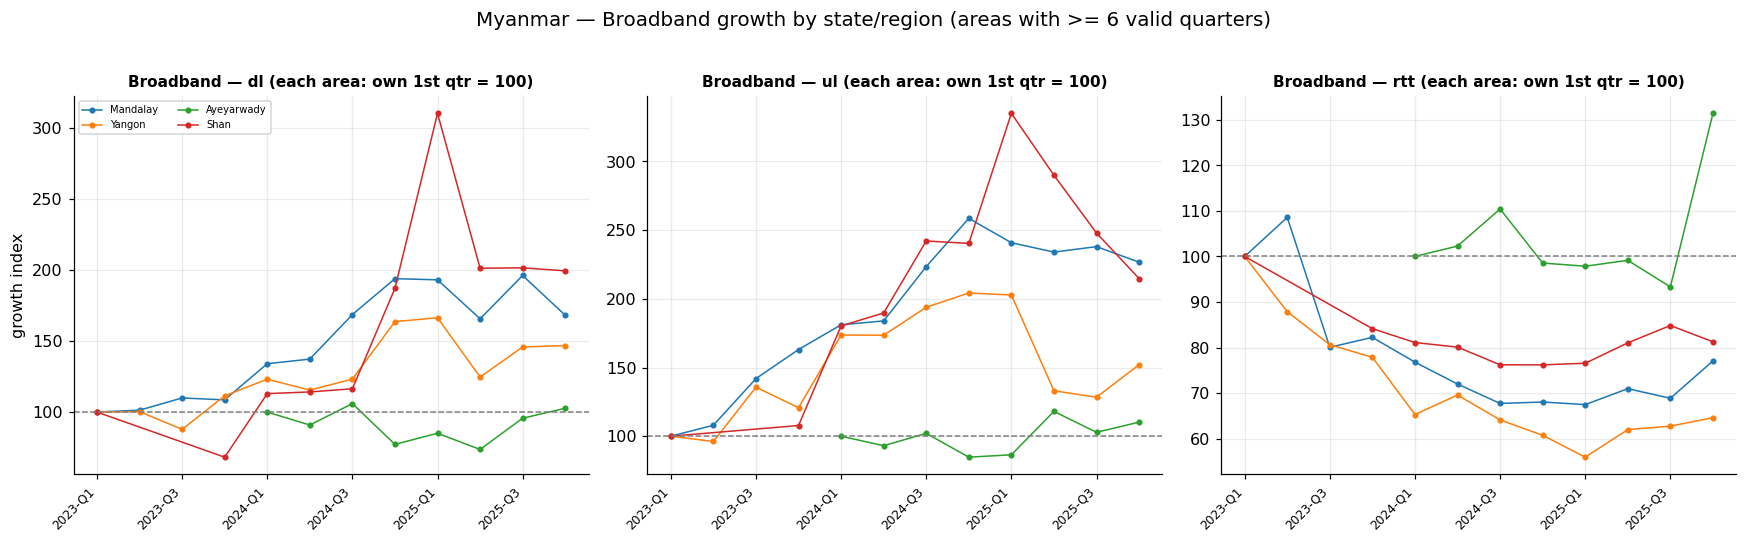

% เปลี่ยนแปลงระดับประเทศ (base = ไตรมาสแรกที่ n>=MIN_N; rtt ลบ = latency ดีขึ้น)


,base_q,last_q,dl_%chg,ul_%chg,rtt_%chg
network_type,,,,,
broadband,2023-Q1,2025-Q4,55.5,94.8,-26.7
cellular,2023-Q1,2025-Q4,145.9,217.3,-34.9
hosting,2023-Q1,2025-Q4,-26.9,211.3,100.7


In [9]:
MIN_Q = max(3, len(Q_ORDER) // 2)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, m in zip(axes, METRICS):
    g = qtr[qtr.network_type == "broadband"]
    piv = g.pivot_table(index="province", columns="label", values=m["key"]).reindex(PROV_ORDER)
    piv = piv.reindex(columns=Q_ORDER)
    valid = piv.notna().sum(axis=1)
    keep = valid[valid >= MIN_Q].index.tolist()
    if len(keep) < 2:
        keep = valid.sort_values(ascending=False).head(2).index.tolist()
    keep = [k for k in keep if valid[k] >= 2]
    if len(keep) == 0:
        ax.text(0.5, 0.5, "not enough data", transform=ax.transAxes, ha="center"); continue
    for reg in keep:
        s = piv.loc[reg].dropna()
        xs = [Q_ORDER.index(q) for q in s.index]
        ax.plot(xs, s.values / s.iloc[0] * 100, marker="o", ms=3, lw=1, label=reg)
    ax.axhline(100, color="grey", ls="--", lw=1)
    step = max(1, len(Q_ORDER) // 6)
    ax.set_xticks(range(0, len(Q_ORDER), step))
    ax.set_xticklabels(Q_ORDER[::step], rotation=45, ha="right", fontsize=8)
    ax.set_title(f"Broadband — {m['key']} (each area: own 1st qtr = 100)", fontsize=10, fontweight="bold")
axes[0].set_ylabel("growth index"); axes[0].legend(fontsize=6.5, ncol=2)
plt.suptitle(f"{COUNTRY} — Broadband growth by {UNIT_EN} (areas with >= {MIN_Q} valid quarters)",
             fontsize=13, y=1.02)
plt.tight_layout(); savefig("05_growth_lines"); plt.show()

natq = con.execute(f"""
    SELECT network_type, year, ((month-1)//3 + 1) AS q,
           make_date(year, CAST(((month-1)//3)*3 + 1 AS INT), 1) AS period_start,
           {AGG}, COUNT(*) AS n
    FROM {P} GROUP BY network_type, year, q, period_start ORDER BY period_start
""").df()
natq["label"] = natq["year"].astype(str) + "-Q" + natq["q"].astype(int).astype(str)
recs = []
for nt in NETS:
    d = natq[(natq.network_type == nt) & (natq.n >= MIN_N)].sort_values("period_start")
    if len(d) < 2: continue
    row = {"network_type": nt, "base_q": d.iloc[0]["label"], "last_q": d.iloc[-1]["label"]}
    for m in METRICS:
        s, e = d.iloc[0][m["key"]], d.iloc[-1][m["key"]]
        row[f"{m['key']}_%chg"] = round((e/s - 1)*100, 1) if s and not np.isnan(s) else np.nan
    recs.append(row)
print("% เปลี่ยนแปลงระดับประเทศ (base = ไตรมาสแรกที่ n>=MIN_N; rtt ลบ = latency ดีขึ้น)")
pd.DataFrame(recs).set_index("network_type")

## 6. Choropleth — GADM ADM1
แผนที่ 3 metric × 2 net · speed เขียว=เร็ว · latency เขียว=ต่ำ · พื้นที่ไม่มีเทสต์=เทา

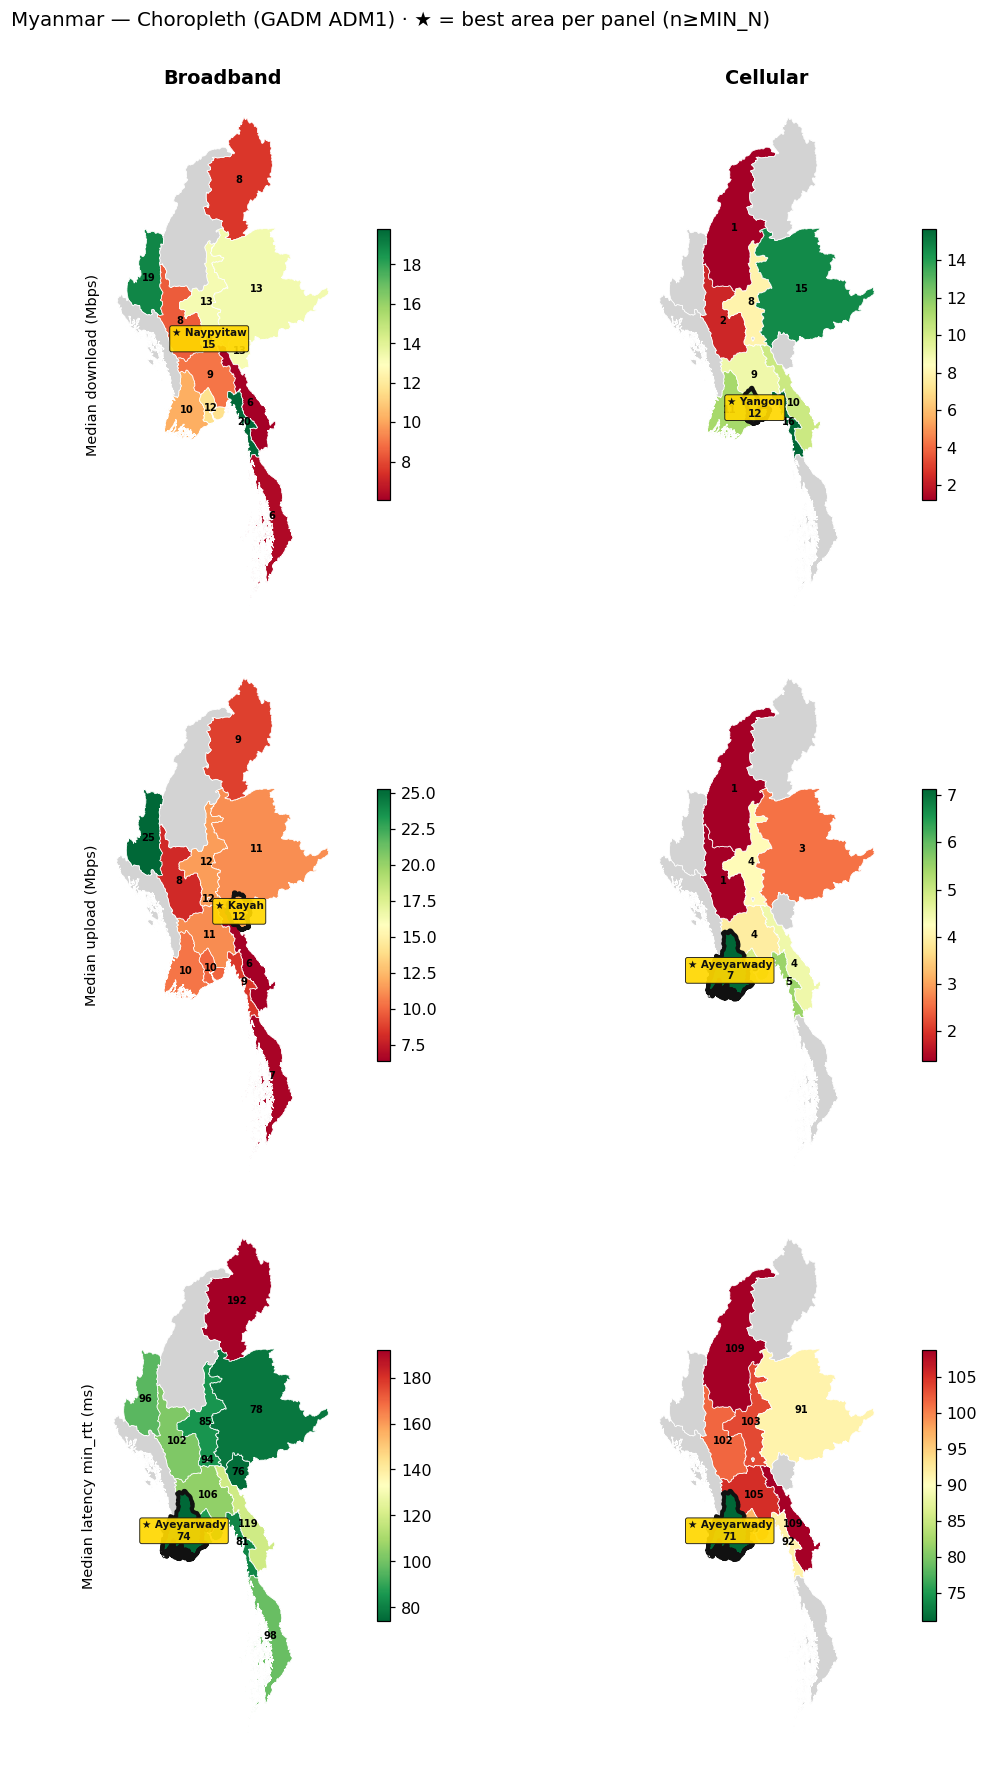

In [10]:
gdf = gpd.read_file(GEOJSON)
fig, axes = plt.subplots(3, 2, figsize=(12, 16))
for ri, m in enumerate(METRICS):
    lower_better = (m["key"] == "rtt")
    for ci, nt in enumerate(USER_NETS):
        ax = axes[ri, ci]
        dat = rm[rm.network_type == nt][["province", m["key"], "n"]]
        geo = gdf.merge(dat, left_on="NAME_1", right_on="province", how="left")
        geo.plot(column=m["key"], ax=ax, cmap=m["cmap"], legend=True,
                 edgecolor="white", linewidth=0.5,
                 legend_kwds={"shrink": 0.5}, missing_kwds={"color": "lightgrey", "label": "no data"})
        cand = geo[geo[m["key"]].notna() & (geo["n"] >= MIN_N)]
        best_prov = None
        if len(cand):
            idx = cand[m["key"]].idxmin() if lower_better else cand[m["key"]].idxmax()
            best_prov = geo.loc[idx, "province"]
            gpd.GeoDataFrame(geometry=[geo.loc[idx, "geometry"]], crs=geo.crs).boundary.plot(
                ax=ax, edgecolor="#111111", linewidth=2.6, zorder=5)
        for _, r in geo.iterrows():
            val = r[m["key"]]
            if pd.isna(val):
                continue
            c = r.geometry.centroid
            if r["province"] == best_prov:
                ax.annotate(f"★ {r['province']}\n{val:.0f}", xy=(c.x, c.y), ha="center", va="center",
                            fontsize=6.8, fontweight="bold", color="#111111", zorder=8,
                            bbox=dict(boxstyle="round,pad=0.2", fc="gold", ec="#111111", lw=0.6, alpha=0.92))
            else:
                ax.annotate(f"{val:.0f}", xy=(c.x, c.y), ha="center", va="center",
                            fontsize=6.5, fontweight="bold")
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values(): sp.set_visible(False)
        if ri == 0: ax.set_title(nt.capitalize(), fontweight="bold")
        if ci == 0: ax.set_ylabel(m["label"], fontsize=9.5)
plt.suptitle(f"{COUNTRY} — Choropleth (GADM ADM1) · ★ = best area per panel (n≥MIN_N)", fontsize=13, y=1.002)
plt.tight_layout(); savefig("06_choropleth"); plt.show()

## 7. City focus — เมืองหลวง + 5 เมืองประชากรสูงสุด
★ = เมืองหลวง (**Nay Pyi Taw**) · 5 เมืองเรียงตามประชากร (ที่มา: สำมะโนประชากรพม่า 2014 (Dept. of Population))

> ⚠️ บางเมืองประชากรสูงแต่ **sample น้อย** → median ไม่เสถียร ตารางติดธง `low-n` (n_user < 1,000)

In [11]:
CITY_LIST = [c for c, _ in TOP_CITIES]
POP = dict(TOP_CITIES)
inlist = ",".join("'" + c.replace("'", "''") + "'" for c in CITY_LIST)

city = con.execute(f"""
    SELECT city,
           ANY_VALUE(province) AS province,
           COUNT(*)                                                        AS n_user,
           100.0*COUNT(*) FILTER (WHERE network_type='broadband')/COUNT(*) AS bb_pct,
           100.0*COUNT(*) FILTER (WHERE network_type='cellular') /COUNT(*) AS cell_pct,
           {AGG}, AVG(loss_rate) AS loss
    FROM {P}
    WHERE city IN ({inlist}) AND category <> 'Hosting/Datacenter'
    GROUP BY city
""").df().set_index("city")

city = city.reindex(CITY_LIST)
city.insert(0, "pop~", [POP[c] for c in CITY_LIST])
city["is_capital"] = ["★" if c == CAPITAL else "" for c in CITY_LIST]
city["flag"] = np.where(city["n_user"] < CITY_FLAG, "low-n", "")
for c in ["dl", "ul", "rtt", "bb_pct", "cell_pct"]:
    city[c] = city[c].round(1)
city["loss"] = city["loss"].round(4)
city["n_user"] = city["n_user"].astype("Int64")

print(f"{COUNTRY} — เมืองหลวง (star)={CAPITAL} · 5 เมืองประชากรสูงสุด")
print(f"low-n = n_user < {CITY_FLAG:,} (median ไม่เสถียร ตีความระวัง)")
city[["pop~", "is_capital", "province", "n_user", "flag",
      "bb_pct", "cell_pct", "dl", "ul", "rtt", "loss"]]

Myanmar — เมืองหลวง (star)=Nay Pyi Taw · 5 เมืองประชากรสูงสุด
low-n = n_user < 1,000 (median ไม่เสถียร ตีความระวัง)


,pop~,is_capital,province,n_user,flag,bb_pct,cell_pct,dl,ul,rtt,loss
city,,,,,,,,,,,
Yangon,5.21M,,Yangon,942654,,80.4,19.6,11.6,9.3,89.6,0.0588
Mandalay,1.22M,,Mandalay,44034,,90.3,9.7,13.3,14.2,80.9,0.0598
Nay Pyi Taw,1.16M,★,Naypyitaw,6547,,100.0,0.0,15.5,11.5,94.2,0.0647
Mawlamyine,491k,,Mon,487,low-n,73.7,26.3,19.0,8.1,82.4,0.0201
Taunggyi,381k,,Shan,3454,,96.8,3.2,10.0,9.9,84.6,0.0731


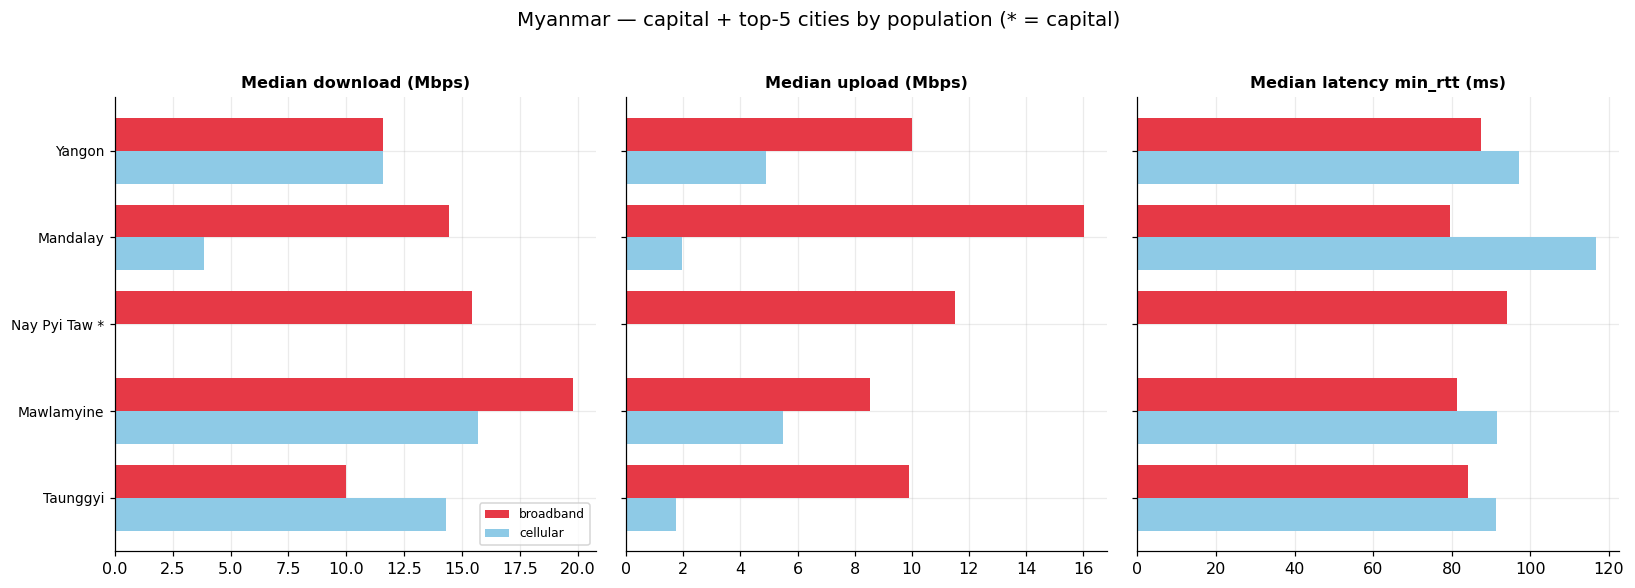

In [12]:
cm = con.execute(f"""
    SELECT city, network_type, {AGG}, COUNT(*) AS n
    FROM {P}
    WHERE city IN ({inlist}) AND category <> 'Hosting/Datacenter'
    GROUP BY city, network_type
""").df()

order = CITY_LIST[::-1]; y = np.arange(len(order)); h = 0.38
fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), sharey=True)
for ax, m in zip(axes, METRICS):
    piv = cm.pivot(index="city", columns="network_type", values=m["key"]).reindex(order)
    for i, nt in enumerate(USER_NETS):
        vals = piv[nt] if nt in piv else pd.Series(index=order, dtype=float)
        ax.barh(y + (0.5 - i)*h, vals, h, label=nt, color=NT_COLOR[nt])
    ax.set_yticks(y)
    ax.set_yticklabels([(c + " *" if c == CAPITAL else c) for c in order], fontsize=9)
    ax.set_title(m["label"], fontsize=10.5, fontweight="bold")
axes[0].legend(fontsize=8, loc="lower right")
plt.suptitle(f"{COUNTRY} — capital + top-5 cities by population (* = capital)", fontsize=13, y=1.02)
plt.tight_layout(); savefig("07_city_bar"); plt.show()

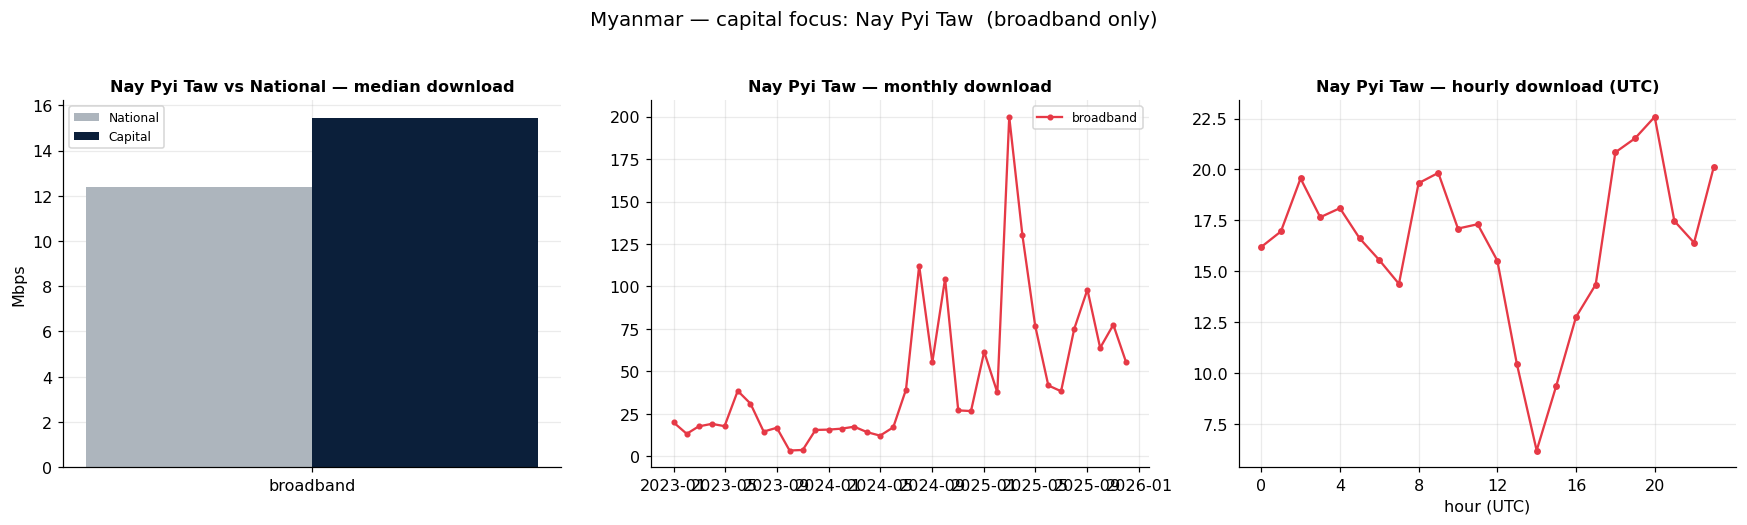

Nay Pyi Taw vs National (ผู้ใช้จริง):


dl                n                rtt               ul  \
scope        Capital National Capital   National Capital National Capital   
network_type                                                                
broadband       15.5     12.4  6547.0  1671466.0    94.2     85.9    11.5   
cellular         NaN      9.9     NaN   333779.0     NaN     99.8     NaN   

                       
scope        National  
network_type           
broadband        10.8  
cellular          4.6

In [13]:
cap_q = CAPITAL.replace("'", "''")
cap_sql = f"city = '{cap_q}'"

cap_cmp = con.execute(f"""
    WITH base AS (SELECT * FROM {P} WHERE category <> 'Hosting/Datacenter')
    SELECT scope, network_type, {AGG}, COUNT(*) n FROM (
        SELECT *, 'National' AS scope FROM base
        UNION ALL SELECT *, 'Capital' AS scope FROM base WHERE {cap_sql}
    ) GROUP BY scope, network_type
""").df()

cap_month = con.execute(f"""
    SELECT network_type, make_date(year, month, 1) AS ym, {AGG}
    FROM {P} WHERE {cap_sql} AND category <> 'Hosting/Datacenter'
    GROUP BY network_type, ym ORDER BY ym""").df()
cap_hour = con.execute(f"""
    SELECT network_type, hour, {AGG}
    FROM {P} WHERE {cap_sql} AND category <> 'Hosting/Datacenter'
    GROUP BY network_type, hour ORDER BY hour""").df()

cap_nets = [nt for nt in USER_NETS
            if nt in set(cap_month["network_type"]) or nt in set(cap_hour["network_type"])]
if not cap_nets:
    cap_nets = list(USER_NETS)
missing = [nt for nt in USER_NETS if nt not in cap_nets]
suffix = f"  ({' + '.join(cap_nets)} only)" if missing else ""

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
piv = cap_cmp.pivot(index="network_type", columns="scope", values="dl").reindex(cap_nets)
x = np.arange(len(cap_nets)); w = 0.35
for i, sc in enumerate(["National", "Capital"]):
    if sc in piv:
        axes[0].bar(x + (i-0.5)*w, piv[sc], w, label=sc,
                    color=(NAVY if sc == "Capital" else "#adb5bd"))
axes[0].set_xticks(x); axes[0].set_xticklabels(cap_nets)
axes[0].set_title(f"{CAPITAL} vs National — median download", fontsize=10.5, fontweight="bold")
axes[0].set_ylabel("Mbps"); axes[0].legend(fontsize=8)
for nt in cap_nets:
    d = cap_month[cap_month.network_type == nt]
    axes[1].plot(d["ym"], d["dl"], marker="o", ms=3, color=NT_COLOR[nt], label=nt)
axes[1].set_title(f"{CAPITAL} — monthly download", fontsize=10.5, fontweight="bold")
axes[1].legend(fontsize=8)
for nt in cap_nets:
    d = cap_hour[cap_hour.network_type == nt]
    axes[2].plot(d["hour"], d["dl"], marker="o", ms=3.5, color=NT_COLOR[nt], label=nt)
axes[2].set_title(f"{CAPITAL} — hourly download (UTC)", fontsize=10.5, fontweight="bold")
axes[2].set_xlabel("hour (UTC)"); axes[2].set_xticks(range(0, 24, 4))
plt.suptitle(f"{COUNTRY} — capital focus: {CAPITAL}{suffix}", fontsize=13, y=1.03)
plt.tight_layout(); savefig("07_capital_focus"); plt.show()

print(f"{CAPITAL} vs National (ผู้ใช้จริง):")
cap_cmp.pivot_table(index="network_type", columns="scope",
                    values=["dl", "ul", "rtt", "n"]).round(1)

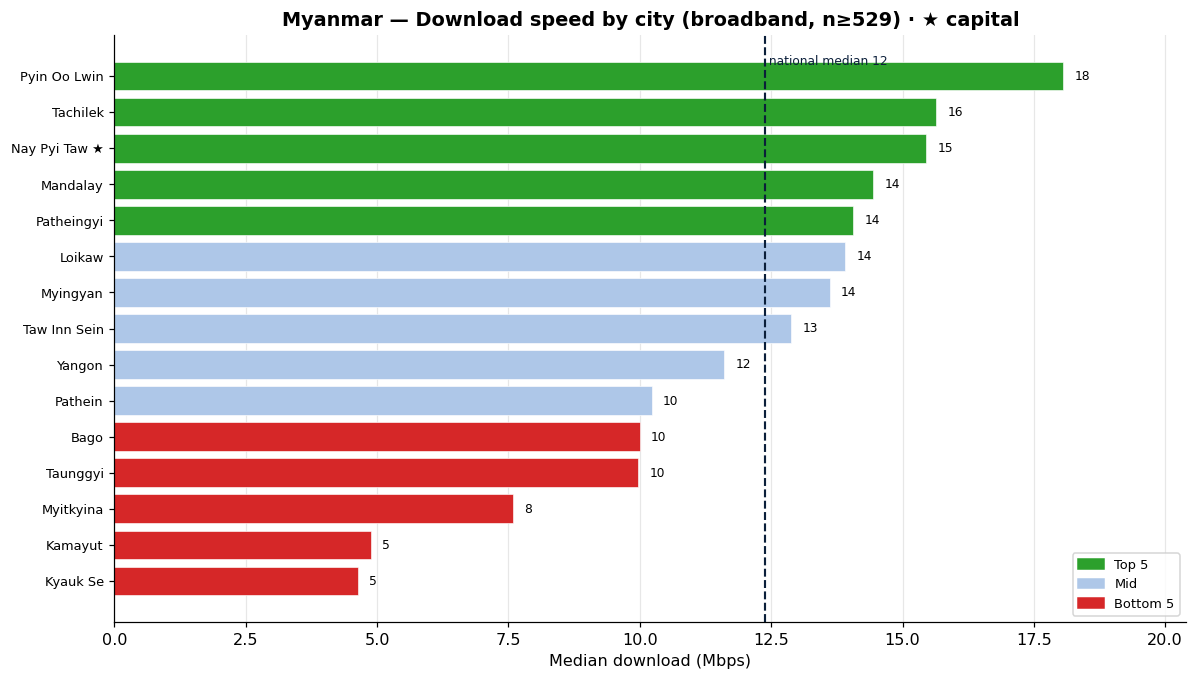

In [14]:
CITY_RANK_MIN = max(100, round(TOTAL / 4000))
cr = con.execute(f"""
    SELECT city, {AGG}, COUNT(*) AS n FROM {P}
    WHERE city IS NOT NULL AND category <> 'Hosting/Datacenter' AND network_type = 'broadband'
    GROUP BY city HAVING COUNT(*) >= {CITY_RANK_MIN}
""").df()
cr = cr.dropna(subset=["dl"]).sort_values("dl", ascending=False).reset_index(drop=True)
nat_dl = con.execute(f"""
    SELECT MEDIAN(mean_throughput_mbps) FROM {P}
    WHERE type = 'download' AND category <> 'Hosting/Datacenter' AND network_type = 'broadband'
""").fetchone()[0]

N = len(cr); k = min(5, max(1, N // 3))
def _rank_color(i):
    if i < k:        return "#2ca02c"
    if i >= N - k:   return "#d62728"
    return "#aec7e8"
cr["c"] = [_rank_color(i) for i in range(N)]
dd = cr.iloc[::-1]
y = np.arange(N)
fig, ax = plt.subplots(figsize=(11, max(5, 0.42 * N)))
ax.barh(y, dd["dl"], color=dd["c"], edgecolor="white", linewidth=0.4)
ax.set_yticks(y)
ax.set_yticklabels([(c + " ★" if c == CAPITAL else c) for c in dd["city"]], fontsize=8.5)
pad = dd["dl"].max() * 0.012
for yi, v in zip(y, dd["dl"]):
    ax.text(v + pad, yi, f"{v:.0f}", va="center", fontsize=8)
ax.axvline(nat_dl, color=NAVY, ls="--", lw=1.4)
ax.text(nat_dl, N - 0.4, f" national median {nat_dl:.0f}", color=NAVY, fontsize=8, va="top")
ax.set_xlim(0, dd["dl"].max() * 1.13)
ax.set_xlabel("Median download (Mbps)")
ax.set_title(f"{COUNTRY} — Download speed by city (broadband, n≥{CITY_RANK_MIN}) · ★ capital", fontweight="bold")
ax.xaxis.grid(True, alpha=0.3); ax.yaxis.grid(False)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in ["#2ca02c", "#aec7e8", "#d62728"]]
ax.legend(handles, [f"Top {k}", "Mid", f"Bottom {k}"], loc="lower right", fontsize=8.5)
plt.tight_layout(); savefig("07_city_distribution"); plt.show()

## 8. Time trend — รายเดือน & รายชั่วโมง
แถวบน = รายเดือน (แนวโน้ม 3 ปี) · แถวล่าง = รายชั่วโมง UTC (peak/off-peak) · broadband+cellular

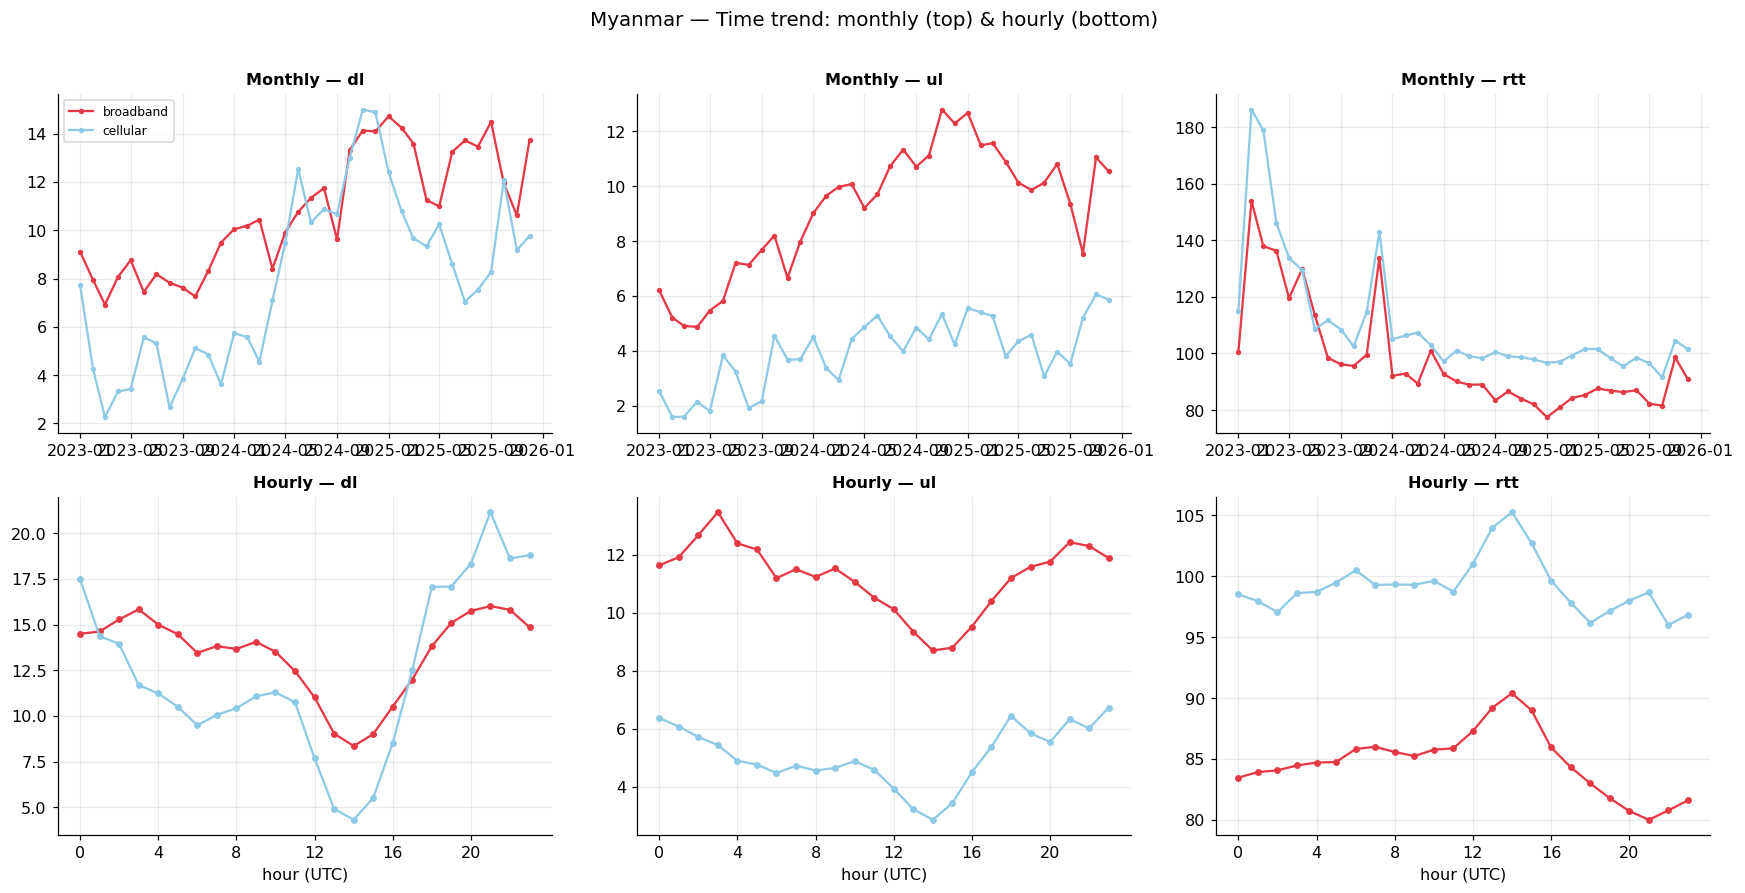

In [15]:
monthly = con.execute(f"""
    SELECT network_type, make_date(year, month, 1) AS ym, {AGG}
    FROM {P} WHERE category <> 'Hosting/Datacenter'
    GROUP BY network_type, ym ORDER BY ym""").df()
hourly = con.execute(f"""
    SELECT network_type, hour, {AGG}
    FROM {P} WHERE category <> 'Hosting/Datacenter'
    GROUP BY network_type, hour ORDER BY hour""").df()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ci, m in enumerate(METRICS):
    for nt in USER_NETS:
        d = monthly[monthly.network_type == nt]
        axes[0, ci].plot(d["ym"], d[m["key"]], marker="o", ms=2.5, color=NT_COLOR[nt], label=nt)
        h = hourly[hourly.network_type == nt]
        axes[1, ci].plot(h["hour"], h[m["key"]], marker="o", ms=3.5, color=NT_COLOR[nt], label=nt)
    axes[0, ci].set_title(f"Monthly — {m['key']}", fontsize=10.5, fontweight="bold")
    axes[1, ci].set_title(f"Hourly — {m['key']}", fontsize=10.5, fontweight="bold")
    axes[1, ci].set_xlabel("hour (UTC)"); axes[1, ci].set_xticks(range(0, 24, 4))
axes[0, 0].legend(fontsize=8)
plt.suptitle(f"{COUNTRY} — Time trend: monthly (top) & hourly (bottom)", fontsize=13, y=1.01)
plt.tight_layout(); savefig("08_time_trend"); plt.show()

## 9. Per-ISP — top ISP
threshold `n≥ISP_MIN` ปรับอัตโนมัติตามขนาดข้อมูล · แท่ง=median download (สีตาม net) · ตารางมี ul/rtt/loss ครบ

ISP_MIN (n>=) = 7,052 | เข้าเกณฑ์ 31 (isp x network_type)


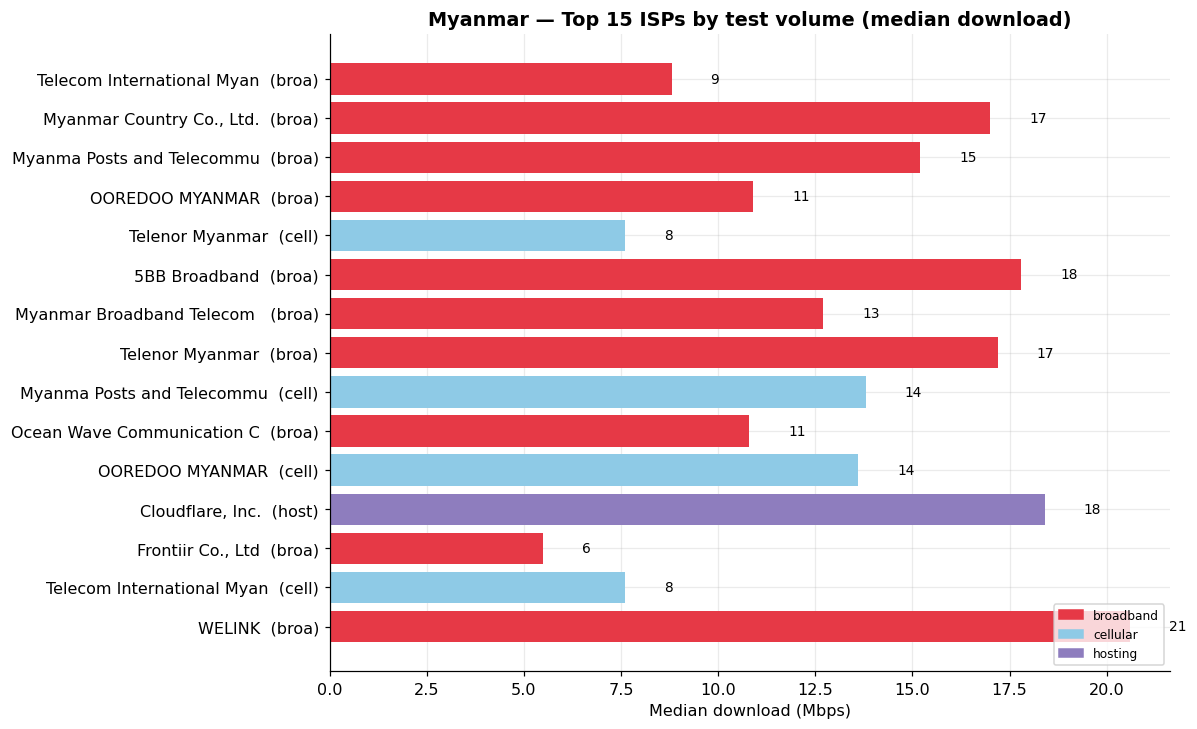

Top 20 ISP (isp x network_type):


,isp,network_type,dl,ul,rtt,loss,n
0,"Telecom International Myanmar Co., Ltd",broadband,8.8,9.6,92.0,0.0808,238851
1,"Myanmar Country Co., Ltd.",broadband,17.0,16.6,78.7,0.0489,217314
2,Myanma Posts and Telecommunications,broadband,15.2,15.1,96.7,0.0696,153782
3,OOREDOO MYANMAR,broadband,10.9,12.8,98.9,0.0739,112635
4,Telenor Myanmar,cellular,7.6,4.4,93.2,0.0362,106991
5,5BB Broadband,broadband,17.8,16.6,71.6,0.0596,104750
6,"Myanmar Broadband Telecom Co., Ltd",broadband,12.7,8.4,79.6,0.0565,84706
7,Telenor Myanmar,broadband,17.2,14.3,88.1,0.0635,82196
8,Myanma Posts and Telecommunications,cellular,13.8,4.3,109.2,0.0143,80785
9,"Ocean Wave Communication Co., Ltd",broadband,10.8,10.5,77.8,0.0709,76425


In [16]:
isp = con.execute(f"""
    SELECT isp, network_type, {AGG}, AVG(loss_rate) AS loss, COUNT(*) AS n
    FROM {P} WHERE isp IS NOT NULL
    GROUP BY isp, network_type
    HAVING COUNT(*) >= {ISP_MIN}
    ORDER BY n DESC
""").df()
isp[["dl", "ul", "rtt"]] = isp[["dl", "ul", "rtt"]].round(1)
isp["loss"] = isp["loss"].round(4)
print(f"ISP_MIN (n>=) = {ISP_MIN:,} | เข้าเกณฑ์ {len(isp)} (isp x network_type)")

top = isp.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(11, max(5, 0.45*len(top))))
bars = ax.barh(top["isp"].str[:26] + "  (" + top["network_type"].str[:4] + ")", top["dl"],
               color=[NT_COLOR[t] for t in top["network_type"]])
for b, v in zip(bars, top["dl"]):
    ax.text(v + 1, b.get_y() + b.get_height()/2, f"{v:.0f}", va="center", fontsize=9)
ax.set_xlabel("Median download (Mbps)")
ax.set_title(f"{COUNTRY} — Top 15 ISPs by test volume (median download)", fontweight="bold")
handles = [plt.Rectangle((0, 0), 1, 1, color=NT_COLOR[t]) for t in NETS]
ax.legend(handles, NETS, fontsize=8, loc="lower right")
plt.tight_layout(); savefig("09_per_isp"); plt.show()

print("Top 20 ISP (isp x network_type):")
isp.head(20).reset_index(drop=True)

## 9.5 Market share — จำนวน ISP และส่วนแบ่งตลาด
นับจากเทสต์ผู้ใช้จริง (ตัด hosting) · แสดง top 8 + **Others** (ที่เหลือรวมกัน) + **(unknown)** = M-Lab ไม่มีชื่อ ISP

> **HHI** (Herfindahl index) = ดัชนีการกระจุกตัวของตลาด: <1500 แข่งขันสูง · 1500–2500 ปานกลาง · >2500 กระจุกตัวสูง

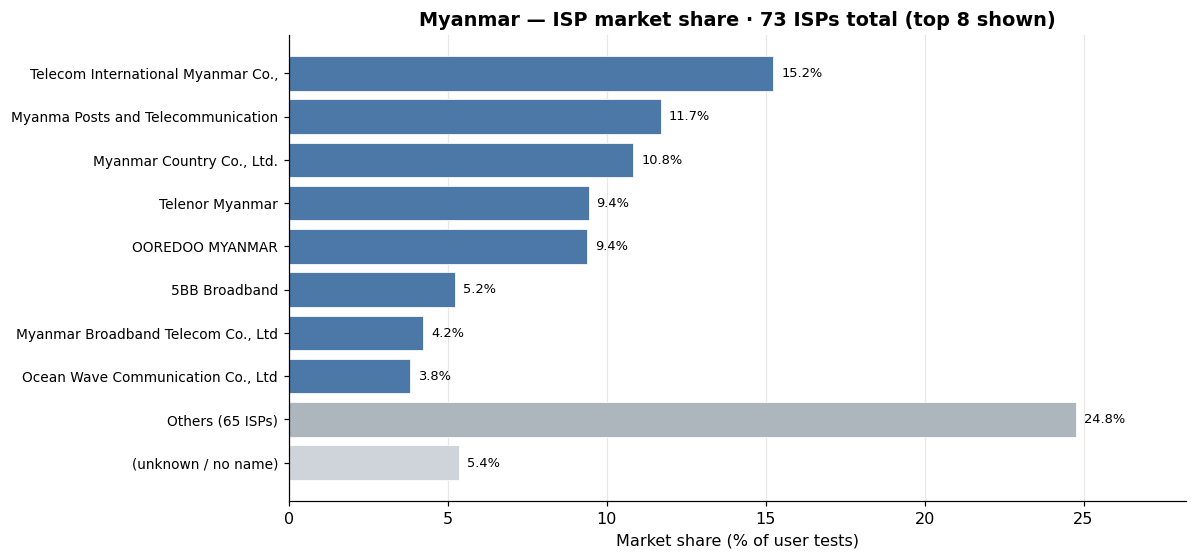

Myanmar: 73 ISPs | Top5 = 56.6% | unknown = 5.4% | HHI = 769 (แข่งขันสูง)


,isp,n,share
0,"Telecom International Myanmar Co., Ltd",305640,15.24
1,Myanma Posts and Telecommunications,234567,11.70
2,"Myanmar Country Co., Ltd.",217314,10.84
3,Telenor Myanmar,189187,9.43
4,OOREDOO MYANMAR,188393,9.40
5,(unknown),107655,5.37
6,5BB Broadband,104750,5.22
7,"Myanmar Broadband Telecom Co., Ltd",84706,4.22


In [17]:
mkt = con.execute(f"""
    SELECT COALESCE(isp, '(unknown)') AS isp, COUNT(*) AS n
    FROM {P} WHERE category <> 'Hosting/Datacenter'
    GROUP BY 1 ORDER BY n DESC
""").df()
total_u = int(mkt["n"].sum())
n_isp = con.execute(f"""SELECT COUNT(DISTINCT isp) FROM {P}
    WHERE isp IS NOT NULL AND category <> 'Hosting/Datacenter'""").fetchone()[0]
mkt["share"] = 100 * mkt["n"] / total_u

TOPN = 8
named = mkt[mkt["isp"] != "(unknown)"].reset_index(drop=True)
unknown_share = float(mkt.loc[mkt["isp"] == "(unknown)", "share"].sum())
top = named.head(TOPN)
others_share = float(named["share"].iloc[TOPN:].sum())
top5_share = float(named["share"].head(5).sum())
hhi = float((named["share"] ** 2).sum())

rows = [(s[:34], v) for s, v in zip(top["isp"], top["share"])]
if others_share > 0: rows.append((f"Others ({len(named) - len(top)} ISPs)", others_share))
if unknown_share > 0: rows.append(("(unknown / no name)", unknown_share))
labels = [r[0] for r in rows][::-1]
vals = [r[1] for r in rows][::-1]
def _mc(lab):
    if lab.startswith("Others"): return "#adb5bd"
    if lab.startswith("(unknown"): return "#ced4da"
    return "#4C78A8"
colors = [_mc(l) for l in labels]

y = np.arange(len(vals))
fig, ax = plt.subplots(figsize=(11, max(4.5, 0.52 * len(vals))))
ax.barh(y, vals, color=colors, edgecolor="white", linewidth=0.5)
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=9)
for yi, v in zip(y, vals):
    ax.text(v + max(vals) * 0.01, yi, f"{v:.1f}%", va="center", fontsize=8.5)
ax.set_xlim(0, max(vals) * 1.14)
ax.set_xlabel("Market share (% of user tests)")
ax.set_title(f"{COUNTRY} — ISP market share · {n_isp} ISPs total (top {TOPN} shown)", fontweight="bold")
ax.xaxis.grid(True, alpha=0.3); ax.yaxis.grid(False)
plt.tight_layout(); savefig("11_market_share"); plt.show()

hhi_note = "แข่งขันสูง" if hhi < 1500 else ("ปานกลาง" if hhi < 2500 else "กระจุกตัวสูง")
print(f"{COUNTRY}: {n_isp} ISPs | Top5 = {top5_share:.1f}% | unknown = {unknown_share:.1f}% "
      f"| HHI = {hhi:.0f} ({hhi_note})")
mkt.head(TOPN)[["isp", "n", "share"]].round(2).reset_index(drop=True)

## 10. Anomaly detection — ISP ที่ผิดปกติ
กฎ IQR ภายในแต่ละ network_type: `high_rtt` / `high_loss` / `low_dl`

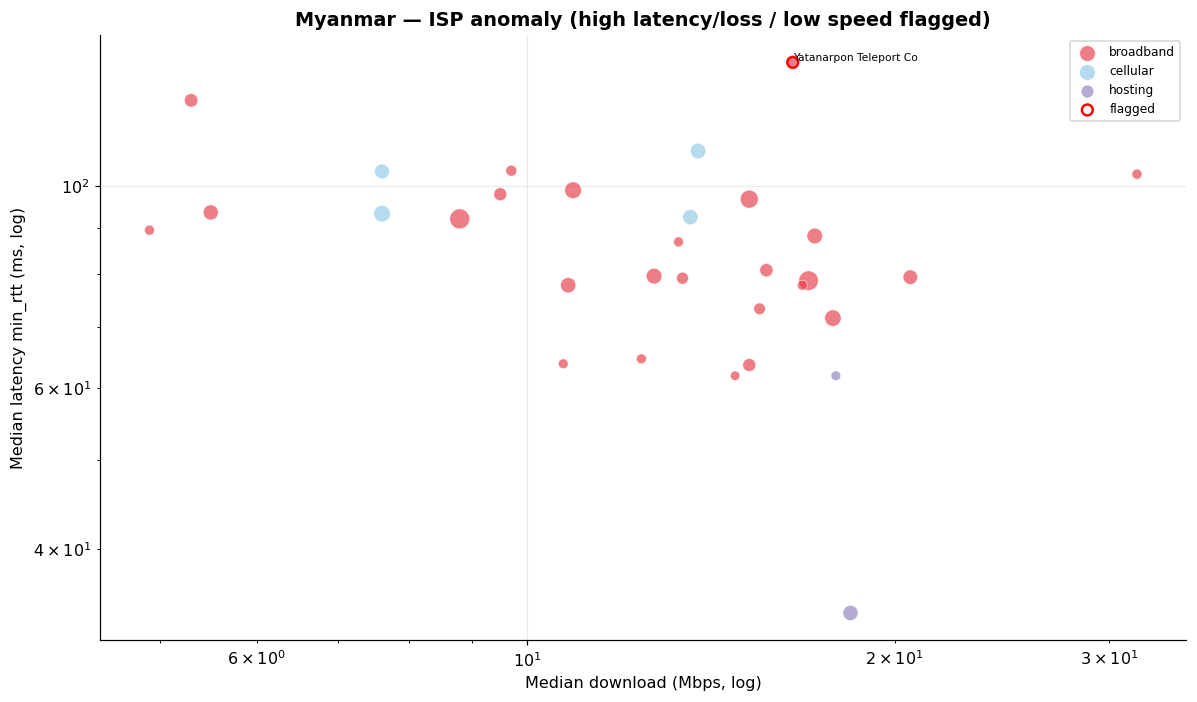

flagged ISP: 1 / 31


,isp,network_type,dl,ul,rtt,loss,n,flags
0,Yatanarpon Teleport Company Limited,broadband,16.5,18.5,136.6,0.0723,16313,high_rtt


In [18]:
def iqr_flags(df):
    df = df.copy(); df["flags"] = ""
    for nt, g in df.groupby("network_type"):
        if len(g) < 4: continue
        for col, high_bad, tag in [("rtt", True, "high_rtt"), ("loss", True, "high_loss"), ("dl", False, "low_dl")]:
            q1, q3 = g[col].quantile([.25, .75]); iqr = q3 - q1
            mask = g[col] > q3 + 1.5*iqr if high_bad else g[col] < q1 - 1.5*iqr
            for i in g[mask].index:
                df.at[i, "flags"] = (df.at[i, "flags"] + "," + tag).strip(",")
    return df

flagged = iqr_flags(isp)
anom = flagged[flagged["flags"] != ""].sort_values("n", ascending=False)

fig, ax = plt.subplots(figsize=(11, 6.5))
for nt in NETS:
    d = flagged[flagged.network_type == nt]
    ax.scatter(d["dl"], d["rtt"], s=np.sqrt(d["n"])/3 + 8, color=NT_COLOR[nt],
               alpha=0.65, edgecolors="white", linewidth=0.5, label=nt)
ax.scatter(anom["dl"], anom["rtt"], s=np.sqrt(anom["n"])/3 + 8, facecolors="none",
           edgecolors="red", linewidth=1.6, label="flagged")
for _, r in anom.iterrows():
    ax.annotate(str(r["isp"])[:22], (r["dl"], r["rtt"]), fontsize=7, ha="left", va="bottom")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Median download (Mbps, log)"); ax.set_ylabel("Median latency min_rtt (ms, log)")
ax.set_title(f"{COUNTRY} — ISP anomaly (high latency/loss / low speed flagged)", fontweight="bold")
ax.legend(fontsize=8)
plt.tight_layout(); savefig("10_anomaly"); plt.show()

print(f"flagged ISP: {len(anom)} / {len(isp)}")
anom[["isp", "network_type", "dl", "ul", "rtt", "loss", "n", "flags"]].reset_index(drop=True)

---
### สรุป
- section 1–2 เห็นภาพรวมครบ 3 network_type · section 3–7 เจาะผู้ใช้จริง (broadband+cellular)
- **เชิงพื้นที่** (รัฐ/ภาค + choropleth) เห็นความเหลื่อมล้ำระหว่างพื้นที่
- **City focus** เจาะเมืองหลวง Nay Pyi Taw + 5 เมืองใหญ่ (ระวังเมือง sample น้อย)
- **Per-ISP / Anomaly** เทียบผู้ให้บริการ + จับ ISP ที่ผิดปกติในกลุ่มเดียวกัน